In [6]:
import os, random, glob
import numpy as np
import tensorflow as tf
import pandas as pd

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
        print(f"GPU detected: {gpus[0].name}")
    except Exception as e:
        print("Could not set memory growth:", e)
else:
    print("No GPU detected. Training will be slower.")

DATA_ROOT = "/kaggle/input/gan-dataset"
FINAL_DATA_DIR = DATA_ROOT

print("DATA_ROOT:", DATA_ROOT)
print("FINAL_DATA_DIR:", FINAL_DATA_DIR)

assert os.path.exists(FINAL_DATA_DIR), f"Dataset not found at: {FINAL_DATA_DIR}"

class_dirs = [d for d in os.listdir(FINAL_DATA_DIR)
              if os.path.isdir(os.path.join(FINAL_DATA_DIR, d))]
class_dirs = sorted(class_dirs)
assert len(class_dirs) > 0, "No class folders found under dataset."

IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp")
total_images = 0
data_summary = []

for cls in class_dirs:
    cls_path = os.path.join(FINAL_DATA_DIR, cls)
    files = [f for f in glob.glob(os.path.join(cls_path, "**", "*"), recursive=True)
             if f.lower().endswith(IMG_EXTS)]
    data_summary.append({"Class": cls, "Image Count": len(files)})
    total_images += len(files)

df_summary = pd.DataFrame(data_summary)
df_summary.loc[len(df_summary.index)] = ["TOTAL", total_images]

styled_table = (
    df_summary.style
    .set_table_styles([
        {"selector": "thead th", "props": "font-weight: bold; text-align: center; border: 1px solid #ddd;"},
        {"selector": "tbody td", "props": "text-align: center; border: 1px solid #ddd; padding: 8px;"},
    ])
    .apply(lambda x: ['font-weight: bold;' if x.name == len(df_summary)-1 else '' for _ in x], axis=1)
    .hide(axis="index")
)

print("\nPer-class image counts:")
display(styled_table)

print(f"\nClasses ({len(class_dirs)}): {class_dirs}")

CLASS_NAMES = class_dirs
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 32
VAL_SPLIT = 0.2
SEED_DS = SEED

print("\nCell 1 complete. Proceed to data pipeline next.")



GPU detected: /physical_device:GPU:0
DATA_ROOT: /kaggle/input/gan-dataset
FINAL_DATA_DIR: /kaggle/input/gan-dataset

Per-class image counts:


Class,Image Count
3_long_blade_rotor,2399
3_short_blade_rotor,2400
Bird,2400
Bird+mini-helicopter,2407
RC_plane,2400
drone,2417
TOTAL,14423



Classes (6): ['3_long_blade_rotor', '3_short_blade_rotor', 'Bird', 'Bird+mini-helicopter', 'RC_plane', 'drone']

Cell 1 complete. Proceed to data pipeline next.


In [8]:
# ---------------------- Cell 2: Data Pipeline & Class Weights (Kaggle Version) ----------------------
import tensorflow as tf
import numpy as np
import pandas as pd
import os


train_ds = tf.keras.utils.image_dataset_from_directory(
    FINAL_DATA_DIR,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED_DS,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    FINAL_DATA_DIR,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED_DS,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp")
class_counts = {}
for class_name in CLASS_NAMES:
    class_dir = os.path.join(FINAL_DATA_DIR, class_name)
    count = len([f for f in os.listdir(class_dir) if f.lower().endswith(IMG_EXTS)])
    class_counts[class_name] = count

total = sum(class_counts.values())
n_classes = len(class_counts)


class_weights = {
    i: total / (n_classes * count)
    for i, (cls, count) in enumerate(class_counts.items())
}


df_summary = pd.DataFrame({
    "Class": list(class_counts.keys()),
    "Image Count": list(class_counts.values()),
    "Class Weight": [round(class_weights[i], 3) for i in range(n_classes)]
})

df_summary.loc[len(df_summary.index)] = ["TOTAL", total, "—"]

styled_table = (
    df_summary.style
    .set_table_styles([
        {"selector": "thead th", "props": "font-weight: bold; text-align: center; border: 1px solid #ddd;"},
        {"selector": "tbody td", "props": "text-align: center; border: 1px solid #ddd; padding: 6px;"},
    ])
    .apply(lambda x: ['font-weight: bold;' if x.name == len(df_summary)-1 else '' for _ in x], axis=1)
    .hide(axis="index")
)

print("\n Per-class image counts and weights:")
display(styled_table)

print("\n Cell 2 complete. Proceed to model definition next.")


Found 14423 files belonging to 6 classes.
Using 11539 files for training.
Found 14423 files belonging to 6 classes.
Using 2884 files for validation.

 Per-class image counts and weights:


Class,Image Count,Class Weight
3_long_blade_rotor,2399,1.002000
3_short_blade_rotor,2400,1.002000
Bird,2400,1.002000
Bird+mini-helicopter,2407,0.999000
RC_plane,2400,1.002000
drone,2417,0.995000
TOTAL,14423,—



 Cell 2 complete. Proceed to model definition next.


In [9]:
#  Cell 3: CNN Model Definition
from tensorflow.keras import layers, models, regularizers

def build_model(input_shape=(224, 224, 3), num_classes=len(CLASS_NAMES)):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.30),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.40),

        # Block 4
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.40),

        # Dense Layers
        layers.Flatten(),
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.50),

        # Output Layer
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


model = build_model()
model.summary()
print("\n Cell 3 complete. Proceed to training next.")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 26,871,846 (102.51 MB)

 Trainable params: 26,868,902 (102.50 MB)

 Non-trainable params: 2,944 (11.50 KB)


 Cell 3 complete. Proceed to training next.


In [10]:
#  Cell 4: Model Training 
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


CLASS_WEIGHTS = {i: 1.0 for i in range(6)}


early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6,
    verbose=1
)


EPOCHS = 50
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint, reduce_lr],
    class_weight=CLASS_WEIGHTS
)

print("\n Training complete. Proceed to evaluation next.")



Epoch 1/50
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9027 - loss: 1.7690
Epoch 1: val_accuracy improved from -inf to 0.77393, saving model to best_model.keras
361/361 ━━━━━━━━━━━━━━━━━━━━ 74s 116ms/step - accuracy: 0.9028 - loss: 1.7680 - val_accuracy: 0.7739 - val_loss: 1.6592 - learning_rate: 0.0010
Epoch 2/50
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9664 - loss: 0.6815
Epoch 2: val_accuracy improved from 0.77393 to 0.92302, saving model to best_model.keras
361/361 ━━━━━━━━━━━━━━━━━━━━ 31s 86ms/step - accuracy: 0.9664 - loss: 0.6813 - val_accuracy: 0.9230 - val_loss: 0.6561 - learning_rate: 0.0010
Epoch 3/50
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9779 - loss: 0.4253
Epoch 3: val_accuracy improved from 0.92302 to 0.96637, saving model to best_model.keras
361/361 ━━━━━━━━━━━━━━━━━━━━ 31s 86ms/step - accuracy: 0.9779 - loss: 0.4251 - val_accuracy: 0.9664 - val_loss: 0.4200 - learning_rate: 0.0010
Epoch 4/50
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 75

91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9980 - loss: 0.0194

 Validation Accuracy: 99.62%
 Validation Loss: 0.0280


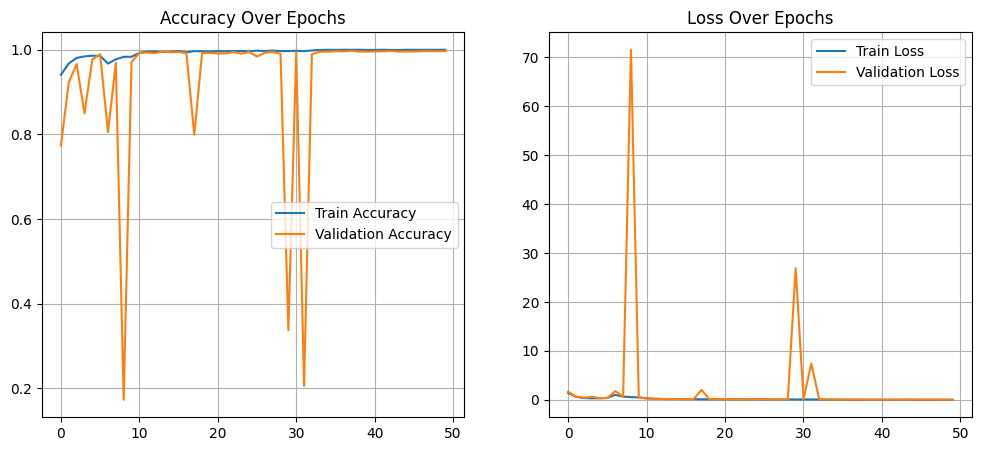

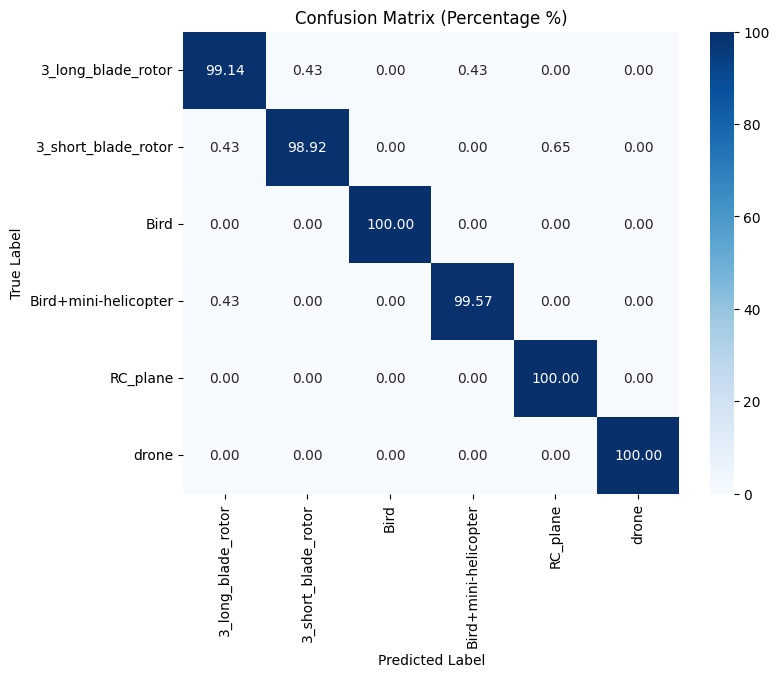


 Classification Report:

                      precision    recall  f1-score   support

  3_long_blade_rotor       0.99      0.99      0.99       463
 3_short_blade_rotor       1.00      0.99      0.99       464
                Bird       1.00      1.00      1.00       498
Bird+mini-helicopter       1.00      1.00      1.00       468
            RC_plane       0.99      1.00      1.00       501
               drone       1.00      1.00      1.00       490

            accuracy                           1.00      2884
           macro avg       1.00      1.00      1.00      2884
        weighted avg       1.00      1.00      1.00      2884



In [11]:

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


class_names = getattr(train_ds, 'class_names', None)
if class_names is None:
    class_names = ['3_long_blade_rotor', '3_short_blade_rotor', 'Bird', 'Bird+mini-helicopter', 'RC_plane', 'drone']

# Evaluate model
val_loss, val_acc = model.evaluate(val_ds)
print(f"\n Validation Accuracy: {val_acc*100:.2f}%")
print(f" Validation Loss: {val_loss:.4f}")


plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()


y_true_list, y_pred_list = [], []

for x_batch, y_batch in val_ds:
    preds = np.argmax(model.predict(x_batch, verbose=0), axis=1)
    if y_batch.ndim > 1:
        y_true_batch = np.argmax(y_batch, axis=1)
    else:
        y_true_batch = y_batch.numpy()
    y_true_list.extend(y_true_batch)
    y_pred_list.extend(preds)

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)


cm = confusion_matrix(y_true, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(8,6))
sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Percentage %)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


print("\n Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))



✅ Common Classes Found: ['Bird', 'drone', 'Bird+mini-helicopter', '3_long_blade_rotor', 'RC_plane', '3_short_blade_rotor']


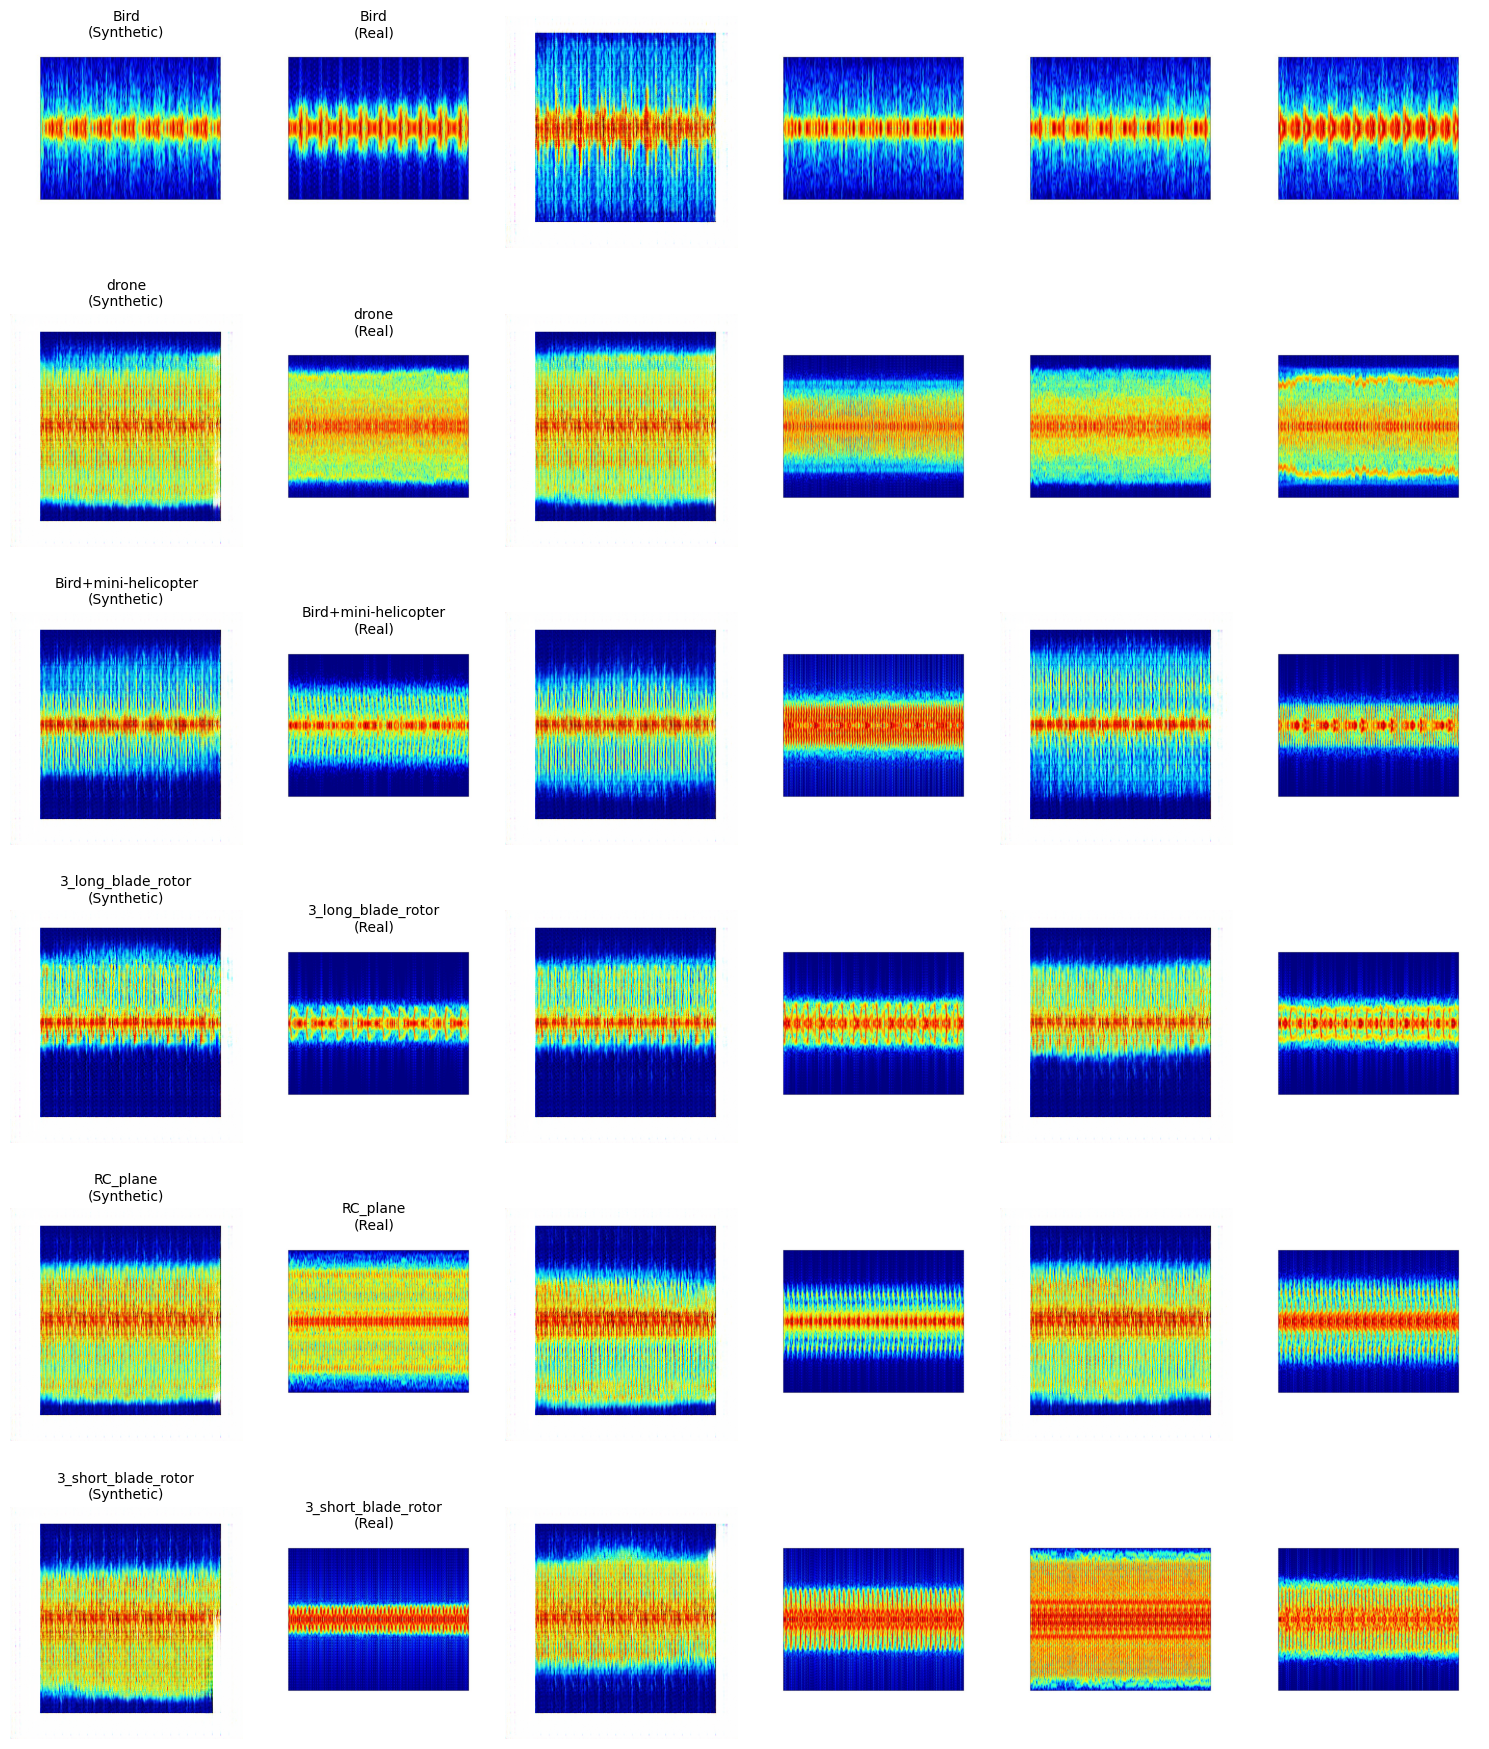

In [9]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Paths (update if needed)
SYNTHETIC_DATA_DIR = "/kaggle/input/gan-dataset"
REAL_DATA_DIR = "/kaggle/input/real-dataset1"

# Get class folders (common subset)
synthetic_classes = sorted(os.listdir(SYNTHETIC_DATA_DIR))
real_classes = sorted(os.listdir(REAL_DATA_DIR))

common_classes = list(set(synthetic_classes) & set(real_classes))
print(f" Common Classes Found: {common_classes}")

# Number of samples to visualize per class
SAMPLES_PER_CLASS = 3

plt.figure(figsize=(15, len(common_classes) * 3))

for i, cls in enumerate(common_classes):
    # Random synthetic & real images
    synth_images = random.sample(os.listdir(os.path.join(SYNTHETIC_DATA_DIR, cls)), SAMPLES_PER_CLASS)
    real_images = random.sample(os.listdir(os.path.join(REAL_DATA_DIR, cls)), SAMPLES_PER_CLASS)

    for j in range(SAMPLES_PER_CLASS):
        # Synthetic
        plt.subplot(len(common_classes), SAMPLES_PER_CLASS * 2, i * SAMPLES_PER_CLASS * 2 + j * 2 + 1)
        synth_path = os.path.join(SYNTHETIC_DATA_DIR, cls, synth_images[j])
        img_synth = mpimg.imread(synth_path)
        plt.imshow(img_synth)
        plt.axis('off')
        if j == 0:
            plt.title(f"{cls}\n(Synthetic)", fontsize=10)

        # Real
        plt.subplot(len(common_classes), SAMPLES_PER_CLASS * 2, i * SAMPLES_PER_CLASS * 2 + j * 2 + 2)
        real_path = os.path.join(REAL_DATA_DIR, cls, real_images[j])
        img_real = mpimg.imread(real_path)
        plt.imshow(img_real)
        plt.axis('off')
        if j == 0:
            plt.title(f"{cls}\n(Real)", fontsize=10)

plt.tight_layout()
plt.show()


In [12]:

import os, numpy as np, tensorflow as tf
from sklearn.metrics import classification_report


REAL_DATA_DIR = "/kaggle/input/real-dataset1"
SYNTH_DATA_DIR = "/kaggle/input/gan-dataset"
MODEL_PATH = "best_model.keras"


real_ds_raw = tf.keras.utils.image_dataset_from_directory(
    REAL_DATA_DIR, image_size=(224,224), batch_size=32, shuffle=False
)
synth_ds_raw = tf.keras.utils.image_dataset_from_directory(
    SYNTH_DATA_DIR, image_size=(224,224), batch_size=32, shuffle=True
)

def dataset_sample_stats(ds, n_batches=1):
    it = iter(ds)
    vals = []
    for _ in range(n_batches):
        try:
            x, _ = next(it)
        except StopIteration:
            break
        x = tf.cast(x, tf.float32)
        vals.append([tf.reduce_mean(x).numpy(), tf.reduce_max(x).numpy()])
    if not vals:
        return None
    vals = np.array(vals)
    return float(vals[:,0].mean()), float(vals[:,1].max())

train_mean, train_max = dataset_sample_stats(synth_ds_raw, n_batches=3)
real_mean, real_max   = dataset_sample_stats(real_ds_raw, n_batches=3)

train_scale = "0-255" if train_max > 1.5 else "0-1"
real_scale  = "0-255" if real_max  > 1.5 else "0-1"
print(f"Detected scales -> Train: {train_scale} | Real: {real_scale}")

# --- Prepare real dataset with matching scale ---
real_ds = tf.keras.utils.image_dataset_from_directory(
    REAL_DATA_DIR, image_size=(224,224), batch_size=32, shuffle=False
)
if train_scale != real_scale:
    if train_scale == "0-1" and real_scale == "0-255":
        real_ds = real_ds.map(lambda x, y: (tf.cast(x, tf.float32)/255.0, y))
        print("Converted real dataset 0–255 → 0–1")
    elif train_scale == "0-255" and real_scale == "0-1":
        real_ds = real_ds.map(lambda x, y: (tf.cast(x, tf.float32)*255.0, y))
        print("Converted real dataset 0–1 → 0–255")

AUTOTUNE = tf.data.AUTOTUNE
real_ds = real_ds.cache().prefetch(buffer_size=AUTOTUNE)


print("\nLoading model...")
model = tf.keras.models.load_model(MODEL_PATH)


loss, acc = model.evaluate(real_ds, verbose=1)
print(f"\n Real Dataset Accuracy: {acc*100:.2f}%")
print(f" Real Dataset Loss: {loss:.4f}")


class_names = sorted([d for d in os.listdir(REAL_DATA_DIR) if os.path.isdir(os.path.join(REAL_DATA_DIR, d))])
y_true, y_pred = [], []
for images, labels in real_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())


print("\nDetailed classification report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

print("\n Evaluation complete — Only accuracy and metrics shown.")


Found 2423 files belonging to 6 classes.
Found 14423 files belonging to 6 classes.
Detected scales -> Train: 0-255 | Real: 0-255
Found 2423 files belonging to 6 classes.

Loading model...
76/76 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.9936 - loss: 0.0662

 Real Dataset Accuracy: 99.75%
 Real Dataset Loss: 0.0327

Detailed classification report:
                      precision    recall  f1-score   support

  3_long_blade_rotor       1.00      0.99      0.99       399
 3_short_blade_rotor       0.99      0.99      0.99       400
                Bird       1.00      1.00      1.00       400
Bird+mini-helicopter       1.00      1.00      1.00       407
            RC_plane       1.00      1.00      1.00       400
               drone       1.00      1.00      1.00       417

            accuracy                           1.00      2423
           macro avg       1.00      1.00      1.00      2423
        weighted avg       1.00      1.00      1.00      2423


✔ Evaluation complete 

76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9932 - loss: 0.0656

 Real Dataset Accuracy: 99.34%
 Real Dataset Loss: 0.0569


 === Model Evaluation Summary ===
          Metric   Value
Overall Accuracy 99.34 %
            Loss  0.0569

 === Per-Class Accuracy ===
          Class Name Accuracy (%)  Correct Predictions  Total Samples
  3_long_blade_rotor        99.50                  397            399
 3_short_blade_rotor        98.75                  395            400
                Bird       100.00                  400            400
Bird+mini-helicopter       100.00                  407            407
            RC_plane        97.75                  391            400
               drone       100.00                  417            417


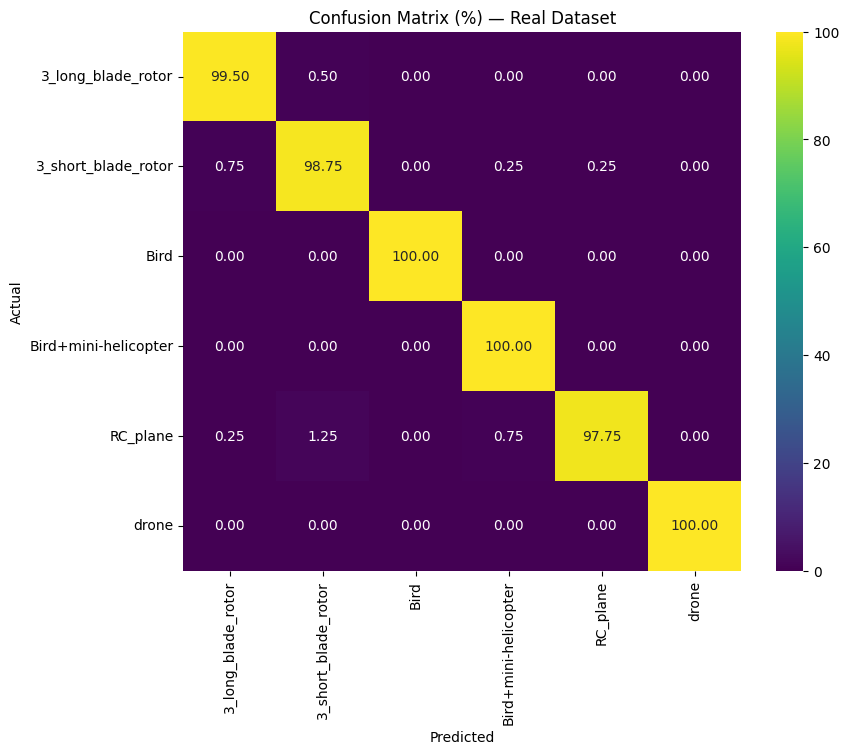


 === Detailed Classification Report ===
                      precision  recall  f1-score   support
3_long_blade_rotor        0.990   0.995     0.992   399.000
3_short_blade_rotor       0.983   0.988     0.985   400.000
Bird                      1.000   1.000     1.000   400.000
Bird+mini-helicopter      0.990   1.000     0.995   407.000
RC_plane                  0.997   0.978     0.987   400.000
drone                     1.000   1.000     1.000   417.000
accuracy                  0.993   0.993     0.993     0.993
macro avg                 0.993   0.993     0.993  2423.000
weighted avg              0.993   0.993     0.993  2423.000

 Metrics exported successfully as CSV files for report & PPT use!


In [13]:
import pandas as pd

# --- Evaluate performance ---
loss, acc = model.evaluate(real_ds, verbose=1)
print(f"\n Real Dataset Accuracy: {acc*100:.2f}%")
print(f" Real Dataset Loss: {loss:.4f}")

# --- Collect predictions ---
y_true, y_pred = [], []
for images, labels in real_ds:
    preds = np.argmax(model.predict(images, verbose=0), axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(preds)
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
cm_percent = np.nan_to_num((cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]) * 100)

# --- Per-class accuracy table ---
per_class_data = []
for i, cls in enumerate(TRAIN_CLASS_NAMES):
    total = cm[i].sum()
    acc_cls = (cm[i, i] / total * 100) if total > 0 else 0
    per_class_data.append({
        "Class Name": cls,
        "Accuracy (%)": f"{acc_cls:.2f}",
        "Correct Predictions": cm[i, i],
        "Total Samples": total
    })

df_metrics = pd.DataFrame(per_class_data)

# --- Global metrics summary ---
summary = pd.DataFrame({
    "Metric": ["Overall Accuracy", "Loss"],
    "Value": [f"{acc*100:.2f} %", f"{loss:.4f}"]
})

# --- Display results neatly ---
print("\n\n === Model Evaluation Summary ===")
print(summary.to_string(index=False))

print("\n === Per-Class Accuracy ===")
print(df_metrics.to_string(index=False))

# --- Confusion Matrix Heatmap ---
plt.figure(figsize=(9, 7))
sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="viridis",
            xticklabels=TRAIN_CLASS_NAMES, yticklabels=TRAIN_CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix (%) — Real Dataset")
plt.show()

# --- Classification Report ---
report = classification_report(y_true, y_pred, target_names=TRAIN_CLASS_NAMES, zero_division=0, output_dict=True)
df_report = pd.DataFrame(report).transpose().round(3)
print("\n === Detailed Classification Report ===")
print(df_report)

# --- Save all metrics for PPT reference ---
df_metrics.to_csv("per_class_accuracy.csv", index=False)
summary.to_csv("overall_summary.csv", index=False)
df_report.to_csv("classification_report.csv")

print("\n Metrics exported successfully as CSV files for report & PPT use!")


Found 6 classes: ['3_long_blade_rotor', '3_short_blade_rotor', 'Bird', 'Bird+mini-helicopter', 'RC_plane', 'drone']


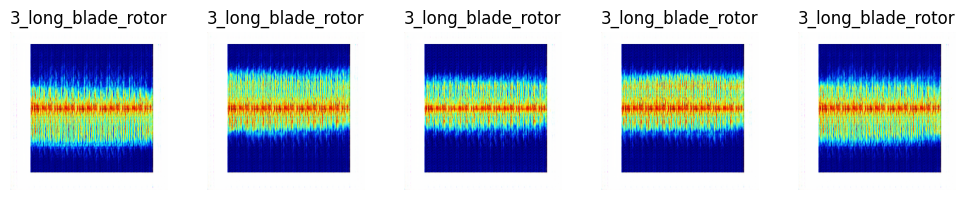

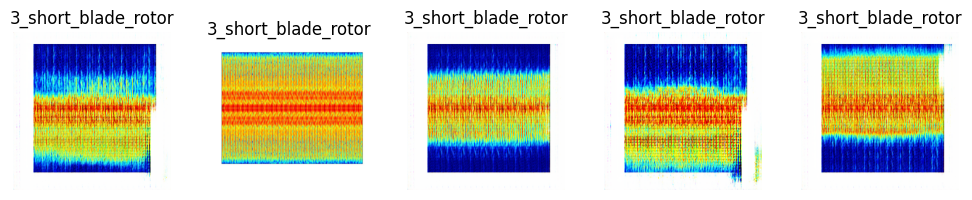

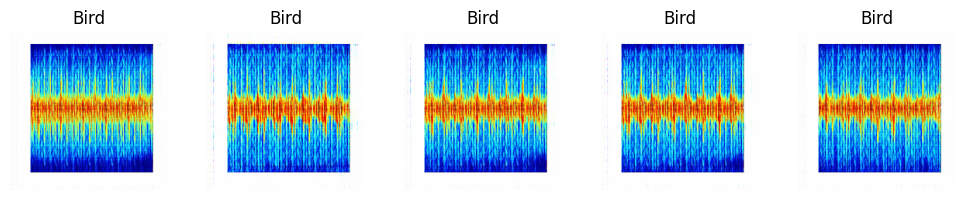

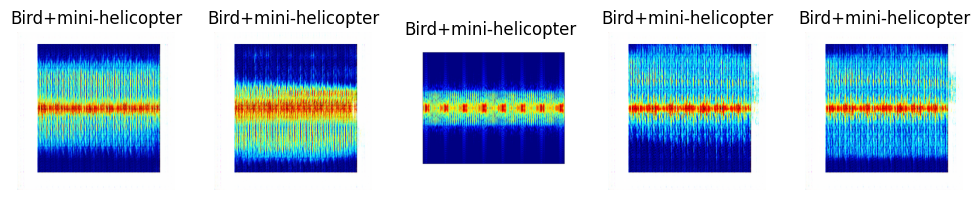

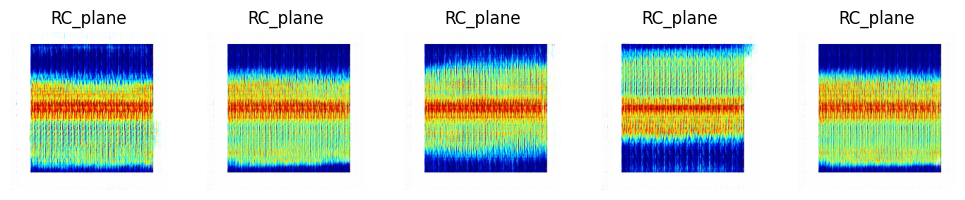

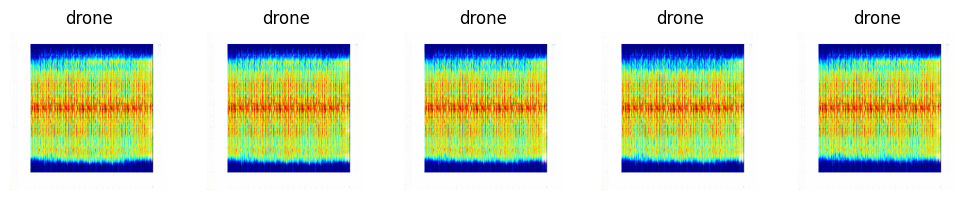

✅ 5 images per class saved and zipped at: /kaggle/working/sample_gan_images.zip


In [14]:
# ---------------------- View & Download 5 Images per Class ----------------------
import os
import random
import matplotlib.pyplot as plt
import shutil
from zipfile import ZipFile

# --- GAN Dataset Path ---
GAN_DATASET_DIR = "/kaggle/input/gan-dataset"
OUTPUT_DIR = "/kaggle/working/sample_gan_images"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Parameters ---
NUM_IMAGES_PER_CLASS = 5

# --- Collect classes ---
class_names = sorted([d for d in os.listdir(GAN_DATASET_DIR) if os.path.isdir(os.path.join(GAN_DATASET_DIR, d))])

# --- Preview & Save ---
print(f"Found {len(class_names)} classes: {class_names}")

for cls in class_names:
    cls_dir = os.path.join(GAN_DATASET_DIR, cls)
    img_files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    selected = random.sample(img_files, min(NUM_IMAGES_PER_CLASS, len(img_files)))
    
    # Create subfolder in output
    save_dir = os.path.join(OUTPUT_DIR, cls)
    os.makedirs(save_dir, exist_ok=True)

    # Copy and display
    for img_name in selected:
        src_path = os.path.join(cls_dir, img_name)
        dst_path = os.path.join(save_dir, img_name)
        shutil.copy(src_path, dst_path)
    
    # Display 5 images
    plt.figure(figsize=(10, 2))
    for i, img_name in enumerate(selected):
        img_path = os.path.join(cls_dir, img_name)
        plt.subplot(1, NUM_IMAGES_PER_CLASS, i + 1)
        plt.imshow(plt.imread(img_path))
        plt.title(cls)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# --- Create ZIP for download ---
zip_path = "/kaggle/working/sample_gan_images.zip"
with ZipFile(zip_path, 'w') as zipf:
    for root, dirs, files in os.walk(OUTPUT_DIR):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, OUTPUT_DIR)
            zipf.write(file_path, arcname)

print(f" 5 images per class saved and zipped at: {zip_path}")


In [20]:
model.save("/kaggle/working/best_model.keras")
np.save("/kaggle/working/y_pred.npy", y_pred)
np.save("/kaggle/working/y_true.npy", y_true)
